In [1]:
import zipfile
import os

zip_file = "archive (6).zip"   # Use the correct, uploaded file path
extract_folder = "/content/plantVillage"

os.makedirs(extract_folder, exist_ok=True)

# Check if the zip file exists before attempting to extract
if not os.path.exists(zip_file):
    print(f"Error: The file '{zip_file}' was not found.")
    print("Please upload the zip file to your Colab environment or ensure the path is correct.")
else:
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_folder)

    print("File unzipped successfully!")


File unzipped successfully!


In [2]:
import os

plant_village_path = '/content/plantVillage'

if os.path.exists(plant_village_path):
    print(f"Contents of {plant_village_path}:")
    for item in os.listdir(plant_village_path):
        print(item)
else:
    print(f"The directory '{plant_village_path}' does not exist. Please ensure the zip file was extracted correctly.")


Contents of /content/plantVillage:
Tomato
Grape
Strawberry
Apple
Potato
Corn (Maize)
Cherry
Peach
Bell Pepper


In [4]:
import os

file_path = 'archive (6).zip'
if os.path.exists(file_path):
    print(f"The file '{file_path}' exists.")
else:
    print(f"The file '{file_path}' does not exist. Please ensure the path is correct and the file is uploaded.")


The file 'archive (6).zip' exists.


In [5]:
import os
print(os.listdir('/content/'))


['.config', 'plantVillage', 'archive (6).zip', 'sample_data']


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np


In [7]:
train_path = '/content/plantVillage_all/Train'
val_path   = '/content/plantVillage_all/Val'
test_path  = '/content/plantVillage_all/Test'


In [9]:
import os

base_path = '/content/plantVillage' # Define base_path here

# Function to list contents recursively
def list_directory_contents(path, indent=0):
    if not os.path.exists(path):
        print(f"  {'  ' * indent}Directory not found: {path}")
        return

    for item in os.listdir(path):
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            print(f"  {'  ' * indent}├── {item}/")
            list_directory_contents(item_path, indent + 1)
        else:
            print(f"  {'  ' * indent}├── {item}")

print(f"Contents of {base_path} (recursive):")
list_directory_contents(base_path)

Streaming output truncated to the last 5000 lines.
        ├── 7b23b182-b353-457d-94db-c4ddd6fdcdd8___Rut._Bact.S 0975.JPG
        ├── bcae2d89-30c3-4f84-9123-51b475e4f2ca___Rutg._Bact.S 2054.JPG
        ├── a5df6abe-61ee-4fbd-bb96-4b9f19979524___Rut._Bact.S 3404.JPG
        ├── 28a75920-daa9-4cd8-926a-6c2813f213f8___Rut._Bact.S 3437.JPG
        ├── 5fc4cdce-4268-4799-b5e6-d229a6d2098d___Rutg._Bact.S 1471.JPG
        ├── 569a1080-059c-49b6-a067-2126ae983064___Rutg._Bact.S 1296.JPG
        ├── 623af1fd-4a0c-48db-85fc-2c1afdf9fd17___Rut._Bact.S 0797.JPG
        ├── 0e272a6e-9a6f-49d7-a599-4a60ac4bdb74___Rut._Bact.S 1548.JPG
        ├── 8cba0a6f-3819-4e42-8e37-356003e2ac8b___Rut._Bact.S 3445.JPG
        ├── a9174977-d345-4bab-9656-c3e7ea7aee08___Rutg._Bact.S 1170.JPG
        ├── 7a39cccc-cab7-445c-bc17-cc0938a5d543___Rut._Bact.S 0922.JPG
        ├── e9afdf82-d64f-438f-b1f0-37800a0f24a1___Rutg._Bact.S 1994.JPG
        ├── 87c48b1a-efa7-4239-b6f1-b7174e3daa29___Rutg._Bact.S 1341.JPG
       

In [10]:
import os
import shutil

base_path = '/content/plantVillage' # Corrected path based on directory listing

main_train = '/content/plantVillage_all/Train'
main_val   = '/content/plantVillage_all/Val'
main_test  = '/content/plantVillage_all/Test'

os.makedirs(main_train, exist_ok=True)
os.makedirs(main_val, exist_ok=True)
os.makedirs(main_test, exist_ok=True)


In [11]:
plants = os.listdir(base_path)

for plant in plants:
    plant_path = os.path.join(base_path, plant)

    if os.path.isdir(plant_path):
        for split in ['Train', 'Val', 'Test']:
            split_path = os.path.join(plant_path, split)

            if os.path.exists(split_path):
                for disease in os.listdir(split_path):
                    src = os.path.join(split_path, disease)

                    if split == 'Train':
                        dst = os.path.join(main_train, disease)
                    elif split == 'Val':
                        dst = os.path.join(main_val, disease)
                    else:
                        dst = os.path.join(main_test, disease)

                    shutil.copytree(src, dst, dirs_exist_ok=True)

print("All plants merged successfully ✅")


All plants merged successfully ✅


In [12]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = val_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)



Found 53693 images belonging to 16 classes.
Found 12067 images belonging to 16 classes.
Found 1358 images belonging to 16 classes.


In [13]:
print("Total classes:", train_data.num_classes)
print(train_data.class_indices)


Total classes: 16
{'Apple Scab': 0, 'Bacterial Spot': 1, 'Black Rot': 2, 'Cedar Apple Rust': 3, 'Cercospora Leaf Spot': 4, 'Common Rust ': 5, 'Early Blight': 6, 'Esca (Black Measles)': 7, 'Healthy': 8, 'Late Blight': 9, 'Leaf Blight': 10, 'Leaf Scorch': 11, 'Northern Leaf Blight': 12, 'Powdery Mildew': 13, 'Septoria Leaf Spot': 14, 'Yellow Leaf Curl Virus': 15}


In [14]:
class_indices = train_data.class_indices
class_names = dict((v, k) for k, v in class_indices.items())


In [15]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)

predictions = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)


In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [18]:
import os

os.listdir('/content')


['.config',
 'plantVillage',
 'archive (6).zip',
 'plantVillage_all',
 'sample_data']

In [19]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=2,
    steps_per_epoch=200,
    validation_steps=50
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
200/200 ━━━━━━━━━━━━━━━━━━━━ 112s 465ms/step - accuracy: 0.5596 - loss: 1.4150 - val_accuracy: 0.8150 - val_loss: 0.5340
Epoch 2/2
200/200 ━━━━━━━━━━━━━━━━━━━━ 74s 373ms/step - accuracy: 0.8452 - loss: 0.4697 - val_accuracy: 0.8694 - val_loss: 0.3943


In [20]:
loss, acc = model.evaluate(val_data)
print("Validation Accuracy:", acc)


378/378 ━━━━━━━━━━━━━━━━━━━━ 32s 85ms/step - accuracy: 0.8732 - loss: 0.3707
Validation Accuracy: 0.8751968145370483


In [21]:
model.save("plant_disease_model.h5")


In [22]:
from google.colab import files
uploaded = files.upload()


Saving healthyappleleaf.jpg to healthyappleleaf.jpg


In [23]:
from google.colab import files
uploaded = files.upload()

Saving potato e blight leaf.jpg to potato e blight leaf.jpg


In [24]:
from google.colab import files
uploaded = files.upload()

Saving tomatoleaf.jpg to tomatoleaf.jpg


In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    "/content/plantVillage",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)


Found 67118 images belonging to 9 classes.


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

Image: healthyappleleaf.jpg
Predicted Disease: Healthy
Confidence: 99.545 %


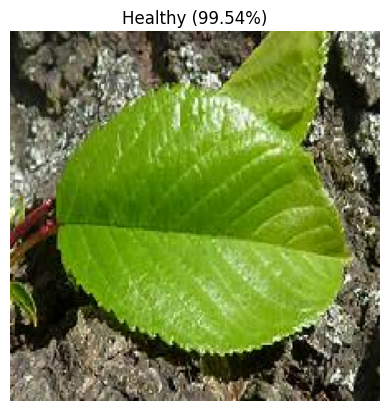

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

Image: potato e blight leaf.jpg
Predicted Disease: Leaf Scorch
Confidence: 60.2886 %


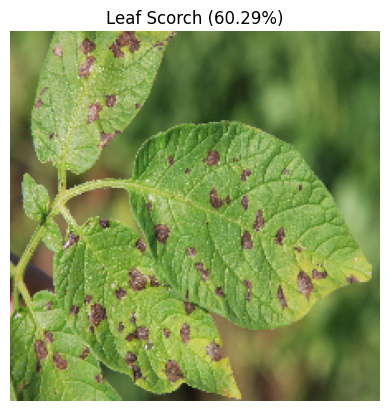

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

Image: tomatoleaf.jpg
Predicted Disease: Leaf Scorch
Confidence: 37.414635 %


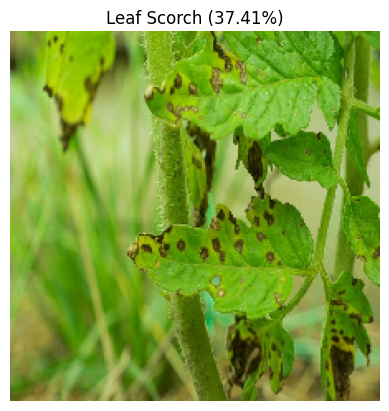

In [29]:
# Load model (only if not already loaded)
from tensorflow.keras.models import load_model
model = load_model("plant_disease_model.h5")

# Imports
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os

# Use the already defined class_names from the training data
# class_names was defined in cell 94Sp_Zl8Qnzo from train_data.class_indices
# and contains the 16 classes the model was trained on.

# List of all uploaded image files
all_uploaded_files = ['healthyappleleaf.jpg', 'potato e blight leaf.jpg', 'tomatoleaf.jpg']

for file_name in all_uploaded_files:
    # Construct the full path to the image file
    full_file_path = os.path.join('/content/', file_name)

    if not os.path.exists(full_file_path):
        print(f"Error: File not found at {full_file_path}. Skipping.")
        continue

    img = image.load_img(full_file_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    predicted_index = np.argmax(prediction)
    confidence = np.max(prediction)

    disease_name = class_names[predicted_index]

    print("\n==============================")
    print("Image:", file_name)
    print("Predicted Disease:", disease_name)
    print("Confidence:", confidence * 100, "%")

    plt.imshow(img)
    plt.title(disease_name + " (" + str(round(confidence*100,2)) + "%)")
    plt.axis("off")
    plt.show()